In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import os
import pandas as pd
plt.style.use(['science','notebook','grid'])
from datetime import datetime as dt

---
---
# Manage results
- pandas dataframe
- save as csv
- read using read() method
- use pd.methods to analyse
- use Data Wrangler

---
---

#                READ DATA FROM STORAGE

---
---

Load data

In [55]:
# read a csv file
filename = "results_4_10_hvl_1e5.csv"
df = pd.read_csv(f"initial_output/simulation_results/{filename}")

In [56]:
df.keys()

Index(['method', 'E0', 'n_hvl_x', 'Srep_index', 'simulation_time_sec',
       'N_stps_per_Nsim', 'buildup_factor', 'n_hvl_y', 'n_hvl_z', 'Nsim',
       'force_first_interaction', 'path_extension_factor', 'weight_min',
       'survival_probability', 'N_out_total', 'E_out_total', 'N_out_primaries',
       'E_out_primaries', 'N_out_secondaries', 'E_out_secondaries',
       'N_backscattered', 'E_backscattered', 'N_leakage', 'E_leakage',
       'N_absorbed', 'E_absorbed', 'N_steps', 'N_stps_per_sec',
       'Nsim_per_sec'],
      dtype='object')

Drep columns

In [61]:
# cleanup - remove unnecessary columns from the dataframe - based on keys names
columns_to_drop = [
    "aa", #! this one is not actual key, errors are ignored using errors="ignore"
    "box_shape_hvl",
    "Nsim",
    "N_steps",
    "force_first_interaction",
    "path_extension_factor",
    "weight_min",
    "survival_probability",
    "box_size_cm",
    "verbosity",
    "Emin_terminate",
    "N_absorbed",
    "E_absorbed",
    "N_stps_per_sec",
    #"N_stps_per_Nsim",
    "Nsim_per_sec",

    # additional
    "n_hvl_y",
    "n_hvl_z",
    "N_out_total",
    "E_out_total",
    #"N_out_primaries",
    "E_out_primaries",
    #"N_out_secondaries",
    "E_out_secondaries",
    "N_backscattered",
    "E_backscattered",
    "N_leakage",
    "E_leakage",
]
df = df.drop(columns=columns_to_drop, errors="ignore")

In [62]:
df.keys()

Index(['method', 'E0', 'n_hvl_x', 'Srep_index', 'simulation_time_sec',
       'N_stps_per_Nsim', 'buildup_factor', 'N_out_primaries',
       'N_out_secondaries'],
      dtype='object')

---
---
# Anaylse methods

In [67]:
# Required columns check
required = {
    "method", "E0", "n_hvl_x", "Srep_index",
    "simulation_time_sec", "buildup_factor",
    "N_out_secondaries", "N_out_primaries"
}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Main aggregated table
summary = (
    df.groupby(["method", "E0", "n_hvl_x"], as_index=False)
      .agg(
          n_rep=("Srep_index", "nunique"),
          t_mean=("simulation_time_sec", "mean"),
          t_std=("simulation_time_sec", "std"),
          B_mean=("buildup_factor", "mean"),
          B_std=("buildup_factor", "std"),
          # rounded mean number of escaping secondaries (integer)
          Nsec_mean=("N_out_secondaries", lambda s: int(np.rint(s.mean()))),
          #Nsec_std=("N_out_secondaries", "std"),
          Nprim_mean=("N_out_primaries", "mean"),
          #Nprim_std=("N_out_primaries", "std"),
      )
)

In [68]:
# change "buildup" method name to "normal"
summary["method"] = summary["method"].replace({"buildup": "normal"})
# change N_stps_per_Nsim key name to stps_per_photon
#summary = summary.rename(columns={"N_stps_per_Nsim": "Nstps_per_photon"})

In [50]:
# # Ratio of escaping secondaries per simulated particle (and in %)
# df["secondary_out_ratio"] = df["N_out_secondaries"] / df["Nsim"]
# df["secondary_out_pct"] = 100.0 * df["secondary_out_ratio"]

# # Remove source columns
# df = df.drop(columns=["Nsim", "N_out_secondaries"], errors="ignore")

# df.head()

,method,E0,n_hvl_x,Srep_index,simulation_time_sec,buildup_factor,N_steps,secondary_out_ratio,secondary_out_pct
0,buildup,0.1,4,0,3.398674,0.990203,101725,0.00094,0.094
1,buildup,0.1,4,1,3.590016,1.031532,101737,0.00091,0.091
2,buildup,0.1,4,2,3.495043,0.994098,101788,0.00105,0.105
3,buildup,0.1,6,0,3.560443,1.025176,101839,0.00020,0.020
4,buildup,0.1,6,1,3.618819,1.000882,101906,0.00023,0.023


In [69]:
# FOM = 1 / (sigma_B^2 * t_mean)
summary["FOM"] = 1.0 / (summary["B_std"]**2 * summary["t_mean"])

# Robustness: if std is zero/NaN -> FOM invalid
summary.loc[~np.isfinite(summary["FOM"]), "FOM"] = np.nan

summary = summary.sort_values(["E0", "n_hvl_x", "method"]).reset_index(drop=True)
summary.head(20)

,method,E0,n_hvl_x,n_rep,t_mean,t_std,B_mean,B_std,Nsec_mean,Nprim_mean,FOM
0,combined_altered,0.1,4,3,20.680047,0.150533,0.000382,0.000011,1716,0.000000,4.337889e+08
1,forcing,0.1,4,3,19.880505,0.114746,1.013622,0.000319,5752,0.000000,4.929427e+05
2,normal,0.1,4,3,3.494578,0.095672,1.005278,0.022820,97,6191.666667,5.494873e+02
3,pdf,0.1,4,3,4.638606,0.017453,1.009016,0.004975,231,24476.666667,8.709251e+03
4,combined_altered,0.1,6,3,20.378840,0.127781,0.000414,0.000010,931,0.000000,4.838675e+08
5,forcing,0.1,6,3,19.725254,0.053201,1.017011,0.000375,1819,0.000000,3.608269e+05
6,normal,0.1,6,3,3.578155,0.035313,1.014276,0.012338,24,1562.000000,1.835963e+03
7,pdf,0.1,6,3,4.661864,0.037937,1.012310,0.011889,139,12022.000000,1.517450e+03
8,combined_altered,0.1,8,3,20.425068,0.214264,0.000453,0.000005,533,0.000000,2.234664e+09
9,forcing,0.1,8,3,19.806688,0.036019,1.020420,0.000293,592,0.000000,5.882220e+05


In [21]:
def show_setup(summary_df, E0, n_hvl_x, method=None):
    q = (summary_df["E0"] == E0) & (summary_df["n_hvl_x"] == n_hvl_x)
    if method is not None:
        q &= (summary_df["method"] == method)

    out = summary_df.loc[q, ["method", "E0", "n_hvl_x", "n_rep", "t_mean", "t_std", "B_mean", "B_std", "FOM"]]
    return out.sort_values("method")

# Examples
E0 = [0.1,0.2,0.5,1.0,2.0,5.0,10.0] [2]
n_hvl_x = [4,6,8,10] [1]
show_setup(summary, E0=E0, n_hvl_x=n_hvl_x)                 # compare all methods at one setup
#show_setup(summary, E0=E0, n_hvl_x=n_hvl_x, method="pdf")   # single method

,method,E0,n_hvl_x,n_rep,t_mean,t_std,B_mean,B_std,FOM
36,buildup,0.5,6,3,12.851450,0.330970,1.409979,0.010969,646.707493
37,combined_altered,0.5,6,3,55.002916,0.504927,0.182363,0.000517,67958.162753
38,forcing,0.5,6,3,60.754230,0.253669,1.423222,0.009457,184.029335
39,pdf,0.5,6,3,13.447366,0.107055,1.423886,0.011242,588.407596


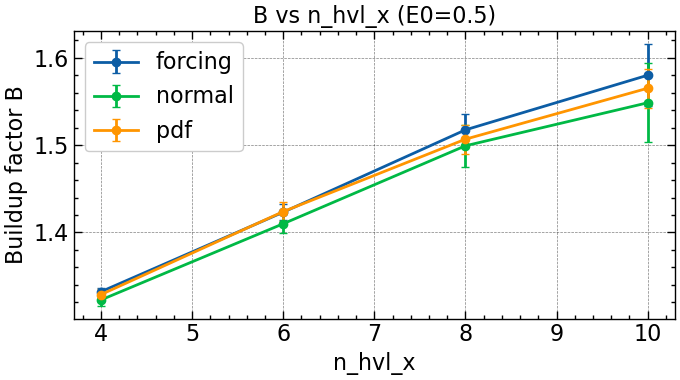

In [33]:
def plot_B_vs_hvl(summary_df, E0, methods_used = ["all"]):
    sub = summary_df[summary_df["E0"] == E0].copy()
    if methods_used != ["all"]:
        sub = sub[sub["method"].isin(methods_used)]
    plt.figure(figsize=(7, 4))
    for m, g in sub.groupby("method"):
        g = g.sort_values("n_hvl_x")
        plt.errorbar(g["n_hvl_x"], g["B_mean"], yerr=g["B_std"], marker="o", capsize=3, label=m)
    plt.xlabel("n_hvl_x")
    plt.ylabel("Buildup factor B")
    plt.title(f"B vs n_hvl_x (E0={E0})")
    plt.legend()
    plt.tight_layout()
    plt.show()

methods_used = ["normal", "pdf", "forcing"]
plot_B_vs_hvl(summary, E0=0.5, methods_used=methods_used)

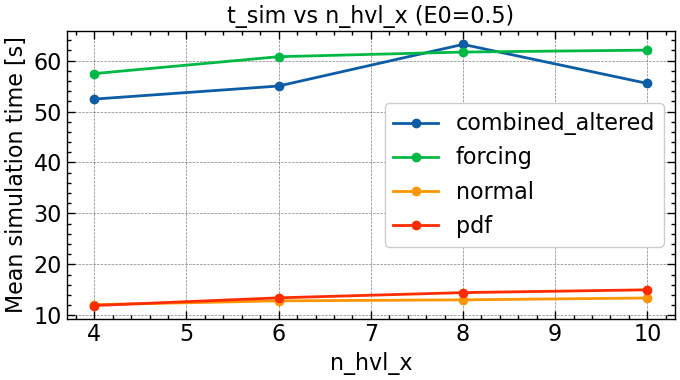

In [34]:
def plot_t_vs_hvl(summary_df, E0):
    sub = summary_df[summary_df["E0"] == E0].copy()
    plt.figure(figsize=(7, 4))
    for m, g in sub.groupby("method"):
        g = g.sort_values("n_hvl_x")
        plt.plot(g["n_hvl_x"], g["t_mean"], marker="o", label=m)
    plt.xlabel("n_hvl_x")
    plt.ylabel("Mean simulation time [s]")
    plt.title(f"t_sim vs n_hvl_x (E0={E0})")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_t_vs_hvl(summary, E0=0.5)

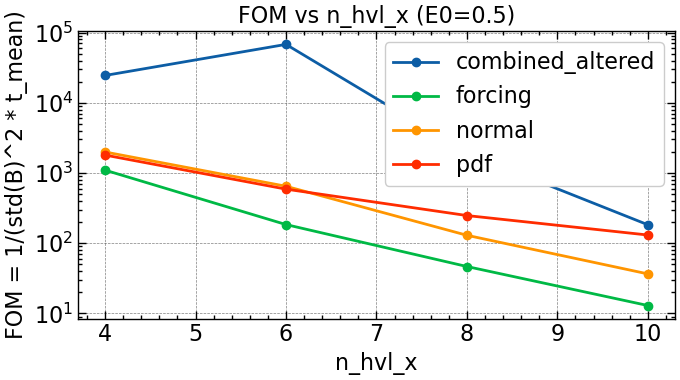

In [36]:
def plot_FOM_vs_hvl(summary_df, E0):
    sub = summary_df[summary_df["E0"] == E0].copy()
    plt.figure(figsize=(7, 4))
    for m, g in sub.groupby("method"):
        g = g.sort_values("n_hvl_x")
        plt.plot(g["n_hvl_x"], g["FOM"], marker="o", label=m)
    plt.xlabel("n_hvl_x")
    plt.ylabel("FOM = 1/(std(B)^2 * t_mean)")
    plt.title(f"FOM vs n_hvl_x (E0={E0})")
    plt.yscale("log")  # often useful
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_FOM_vs_hvl(summary, E0=0.5)

In [37]:
# Baseline table (normal MC)
base = (
    summary[summary["method"] == "buildup"][["E0", "n_hvl_x", "t_mean", "FOM", "B_mean"]]
    .rename(columns={"t_mean": "t_base", "FOM": "FOM_base", "B_mean": "B_base"})
)

cmp = summary.merge(base, on=["E0", "n_hvl_x"], how="left")
cmp["speedup_vs_buildup"] = cmp["t_base"] / cmp["t_mean"]      # >1 is faster
cmp["FOM_gain_vs_buildup"] = cmp["FOM"] / cmp["FOM_base"]      # >1 is better
cmp["B_bias_vs_buildup"] = cmp["B_mean"] - cmp["B_base"]       # near 0 expected

cmp.sort_values(["E0", "n_hvl_x", "method"]).head(20)

,method,E0,n_hvl_x,n_rep,t_mean,t_std,B_mean,B_std,FOM,t_base,FOM_base,B_base,speedup_vs_buildup,FOM_gain_vs_buildup,B_bias_vs_buildup
0,combined_altered,0.1,4,3,20.680047,0.150533,0.000382,0.000011,4.337889e+08,NaN,NaN,NaN,NaN,NaN,NaN
1,forcing,0.1,4,3,19.880505,0.114746,1.013622,0.000319,4.929427e+05,NaN,NaN,NaN,NaN,NaN,NaN
2,normal,0.1,4,3,3.494578,0.095672,1.005278,0.022820,5.494873e+02,NaN,NaN,NaN,NaN,NaN,NaN
3,pdf,0.1,4,3,4.638606,0.017453,1.009016,0.004975,8.709251e+03,NaN,NaN,NaN,NaN,NaN,NaN
4,combined_altered,0.1,6,3,20.378840,0.127781,0.000414,0.000010,4.838675e+08,NaN,NaN,NaN,NaN,NaN,NaN
5,forcing,0.1,6,3,19.725254,0.053201,1.017011,0.000375,3.608269e+05,NaN,NaN,NaN,NaN,NaN,NaN
6,normal,0.1,6,3,3.578155,0.035313,1.014276,0.012338,1.835963e+03,NaN,NaN,NaN,NaN,NaN,NaN
7,pdf,0.1,6,3,4.661864,0.037937,1.012310,0.011889,1.517450e+03,NaN,NaN,NaN,NaN,NaN,NaN
8,combined_altered,0.1,8,3,20.425068,0.214264,0.000453,0.000005,2.234664e+09,NaN,NaN,NaN,NaN,NaN,NaN
9,forcing,0.1,8,3,19.806688,0.036019,1.020420,0.000293,5.882220e+05,NaN,NaN,NaN,NaN,NaN,NaN


---
---
# -------------------------------------------------------------
# --------------------------- OLD -----------------------------
# -------------------------------------------------------------



Group by method, E0, n_hvl_x

In [12]:
grouped = df.groupby(["method", "E0", "n_hvl_x"])

In [7]:
stats = grouped.agg({
    "buildup_factor": ["mean", "std"],
    "simulation_time_sec": "mean"
})

stats["FOM"] = 1 / (stats[("buildup_factor","std")]**2 * stats[("simulation_time_sec","mean")])
stats

buildup_factor           simulation_time_sec          FOM
                              mean       std                mean             
method   E0 n_hvl_x                                                          
buildup  1  2             1.352992  0.010824            2.223213  3838.965402
            4             1.632174  0.077156            2.979797    56.372703
            6             1.870789  0.049421            3.129575   130.826393
         2  2             1.403870  0.021889            3.239564   644.262270
            4             1.819970  0.045933            4.372817   108.390311
            6             2.095462  0.061374            4.844255    54.803152
         5  2             1.231788  0.011859            4.074237  1745.120595
            4             1.520956  0.066258            5.187911    43.907329
            6             1.854958  0.074506            5.556819    32.418117
combined 1  2             1.338844  0.008529            6.077212  2262.048926
            4             1.512592  0.007007            7.072511  2879.418350
            6             1.625688  0.027657            7.649672   170.896874
         2  2             1.478471  0.006000            7.233362  3840.172400
            4             1.763904  0.027434            8.490087   156.493657
            6             2.036600  0.006809            9.221240  2339.393168
         5  2             1.323155  0.007691            9.840641  1717.904204
            4             1.576516  0.023965           13.926208   125.032176
            6             1.794663  0.019944           12.465132   201.679277
forcing  1  2             1.359196  0.004002            7.035409  8873.492674
            4             1.646294  0.012922            8.527381   702.316347
            6             1.906337  0.064274            8.987928    26.931827
         2  2             1.408023  0.003932            8.773723  7372.171072
            4             1.794893  0.019325           12.377656   216.329077
            6             2.129266  0.074779           12.779529    13.993476
         5  2             1.245528  0.006610           12.608971  1815.065825
            4             1.489387  0.018930           14.693082   189.935308
            6             1.780498  0.078157           18.835737     8.691179
pdf      1  2             1.364177  0.008729            1.601780  8193.697194
            4             1.651781  0.037940            2.311682   300.516639
            6             1.871333  0.058586            2.827461   103.042266
         2  2             1.393655  0.011763            2.346567  3080.009527
            4             1.770124  0.019352            3.322846   803.618758
            6             2.140503  0.070962            4.154517    47.800519
         5  2             1.242651  0.014488            2.760283  1725.965231
            4             1.486125  0.034809            4.165702   198.122869
            6             1.766072  0.060839            5.058452    53.410213

In [13]:
tsim_stats_today = grouped.agg({"simulation_time_sec": "mean"})

In [14]:
tsim_stats_today

simulation_time_sec
method  E0   n_hvl_x                     
buildup 0.1  4                   3.494578
             6                   3.578155
             8                   3.549359
             10                  3.570035
        0.2  4                   4.761529
...                                   ...
pdf     5.0  10                 50.820832
        10.0 4                  37.882722
             6                  45.201783
             8                  49.399205
             10                 51.938441

[112 rows x 1 columns]

In [15]:
# calculate main statistics for buildup factor for each method, E0 and N_hvl
df.groupby(["method", "E0", "n_hvl_x"])["buildup_factor"].agg(["mean", "std"])
# add mean time per simulation for each method, E0 and N_hvl
df.groupby(["method", "E0", "n_hvl_x"])["simulation_time_sec"].agg(["mean"])

mean
method  E0   n_hvl_x           
buildup 0.1  4         3.494578
             6         3.578155
             8         3.549359
             10        3.570035
        0.2  4         4.761529
...                         ...
pdf     5.0  10       50.820832
        10.0 4        37.882722
             6        45.201783
             8        49.399205
             10       51.938441

[112 rows x 1 columns]